# Effect of Study Hours on Average Test Scores

The goal of this project is to determine whether total study hours can help predict average test scores. This project uses a supervised Machine Learning technique called a univariate linear regression model, which means the model uses one input feature (study hours) to predict one target value (average test score).

# Installs
Any modules that need to be installed should go here


In [86]:
%pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Imports
Any imports should go here

In [87]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.style.use("ggplot")

# Read the CSV File
You need to load the CSV file into Jupyter then create a data frame (df) using the path to where the file is located

In [88]:
df = pd.read_csv("exam_scores.csv")

# Describe the Data - pandas.dataFrame.describe()
This step gives us summary statistics for each numerical column, including count, mean, standard deviation, minimum, maximum, and quartiles.

In [89]:
df.describe()

,candidate_id,age,total_study_hours,practice_exams_taken,average_practice_score,exam_attempt_number,final_exam_score
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,101.000000,32.666667,29.119403,8.422886,75.375622,1.467662,77.193035
std,58.167861,9.379410,13.583655,4.411947,16.406537,0.741754,16.107118
min,1.000000,18.000000,5.000000,0.000000,40.000000,1.000000,40.000000
25%,51.000000,25.000000,18.000000,5.000000,63.000000,1.000000,66.000000
50%,101.000000,31.000000,30.000000,9.000000,78.000000,1.000000,80.000000
75%,151.000000,41.000000,40.000000,12.000000,90.000000,2.000000,92.000000
max,201.000000,58.000000,50.000000,15.000000,99.000000,5.000000,100.000000


# Storing Columns into Variables
Here we are going to store our training data into variables for use in the model.

In [90]:
scores = df["average_practice_score"]
study_hours = df["total_study_hours"]

# Display Columns
Print the 2 columns we neeed, this is not neccessary but was checked here in case.

In [91]:
display(study_hours)
print("*******************************************************************")
display(scores)

0      38
1      33
2       8
3      20
4      28
       ..
196    30
197    42
198    12
199    25
200     6
Name: total_study_hours, Length: 201, dtype: int64

*******************************************************************


0      85.0
1      79.0
2      50.0
3      68.0
4      69.5
       ... 
196    78.0
197    91.0
198    58.0
199    71.0
200    40.0
Name: average_practice_score, Length: 201, dtype: float64

# Plotting our Data
Plotting test scores x study hours, ensure data is labeled correctly and on the right axis

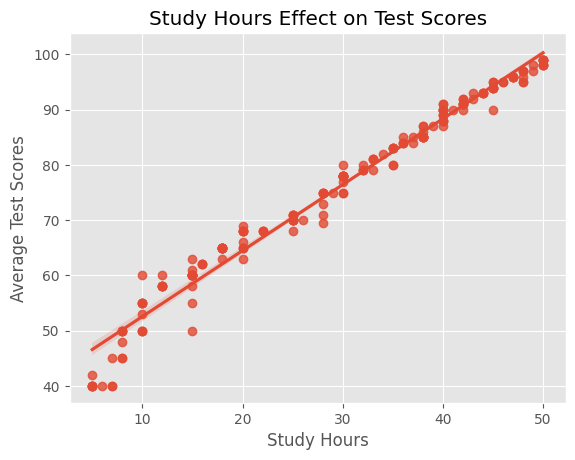

In [92]:
sns.regplot(x=study_hours, y=scores)
plt.title("Study Hours Effect on Test Scores")
plt.xlabel("Study Hours")
plt.ylabel("Average Test Scores")
plt.show()

# Obtaining Weight & Bias, Store in Variables
Using polyfit() to get w & b which are values stored that represent the slope and y-intercept of the line of best fit.

In [93]:
w, b = np.polyfit(study_hours, scores, 1) # Finds the weight/slope and bias/y-intercept for a degree-1 polynomial, which is a straight line.

# Prediction
This is the equation to predict any score based on study hours. We do not like to predict too far outside training data, as this could be unreliable. Also, in this case you cant get higher than a 100%

In [94]:
study_hours_prediction = 47.7
average_score = w * study_hours_prediction + b    
print(f"Hours Studied: {study_hours_prediction} hrs")
print(f"Predicted Average Score: {average_score:.2f} %")

Hours Studied: 47.7 hrs
Predicted Average Score: 97.55 %


# Correlation Check
After `np.polyfit()` finds `w` and `b`, our model has the form: predicted score = w × study hours + b. A correlation of 0.99 means study hours and average practice score have a very strong positive linear relationship in this dataset. As study hours increase, average practice scores usually increase too. Correlation does not prove causation. It shows that the two variables move together, but it does not automatically prove that study hours are the only reason scores increased.

In [85]:
correlation = study_hours.corr(scores)
print(f"Correlation: {correlation:.2f}")

Correlation: 0.99
